<a href="https://colab.research.google.com/github/2025aarant-wq/Alpha-/blob/main/Equity_Risk_Decomposition_Using_CAPM_A_Comparative_Study_of_Systematic_and_Idiosyncratic_Risk_in_Indian_Stock_Markets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

print("All libraries imported successfully.")

All libraries imported successfully.


In [7]:
STOCKS = {
    # Ticker         : Sector
    'RELIANCE.NS'    : 'Energy',
    'TCS.NS'         : 'IT',
    'INFY.NS'        : 'IT',
    'HDFCBANK.NS'    : 'Financials',
    'ICICIBANK.NS'   : 'Financials',
    'AXISBANK.NS'    : 'Financials',
    'ITC.NS'         : 'FMCG',
    'HINDUNILVR.NS'  : 'FMCG',
    'MARUTI.NS'      : 'Auto',
    'M&M.NS'         : 'Auto', # Replaced TATAMOTORS.NS with M&M.NS
    'SUNPHARMA.NS'   : 'Pharma',
    'DRREDDY.NS'     : 'Pharma',
}

MARKET_TICKER = '^NSEI'          # Nifty 50
START         = '2016-01-01'
END           = '2026-01-01'

tickers = list(STOCKS.keys())

print(f"Downloading {len(tickers)} stocks + Nifty 50 from {START} to {END} ...")

# Download stock prices
raw_stocks = yf.download(tickers, start=START, end=END, auto_adjust=True, progress=False)

# Download market index
raw_market = yf.download(MARKET_TICKER, start=START, end=END, auto_adjust=True, progress=False)

print("Download complete.")
print(f"Stock data shape : {raw_stocks.shape}")
print(f"Market data shape: {raw_market.shape}")

Download complete.
Stock data shape : (2470, 60)
Market data shape: (2464, 5)


In [8]:
# ── Extract closing prices (compatible with yfinance 0.2+) ───────────────────
def extract_close(df):
    """Returns the Close price DataFrame regardless of yfinance column structure."""
    if isinstance(df.columns, pd.MultiIndex):
        # Multi-ticker download has columns like ('Close', 'RELIANCE.NS')
        try:
            return df['Adj Close']
        except KeyError:
            return df['Close']
    else:
        try:
            return df[['Adj Close']].squeeze()
        except KeyError:
            return df[['Close']].squeeze()

prices        = extract_close(raw_stocks)   # DataFrame: date × ticker
market_prices = extract_close(raw_market)   # Series: date

# ── Compute daily percentage returns: (P_t / P_{t-1}) - 1 ────────────────────
stock_returns  = prices.pct_change().dropna()                         # DataFrame
market_returns = market_prices.pct_change().dropna().squeeze().rename('Market') # Series

# ── Align on common trading dates ────────────────────────────────────────────
data = stock_returns.join(market_returns, how='inner').dropna()

print(f"Combined DataFrame shape: {data.shape}")
print(f"Date range             : {data.index[0].date()} → {data.index[-1].date()}")
print(f"\nNull values per column:\n{data.isnull().sum().to_string()}")
print(f"\nFirst 3 rows:")
data.head(3)

Combined DataFrame shape: (2463, 13)
Date range             : 2016-01-05 → 2025-12-31

Null values per column:
AXISBANK.NS      0
DRREDDY.NS       0
HDFCBANK.NS      0
HINDUNILVR.NS    0
ICICIBANK.NS     0
INFY.NS          0
ITC.NS           0
M&M.NS           0
MARUTI.NS        0
RELIANCE.NS      0
SUNPHARMA.NS     0
TCS.NS           0
Market           0

First 3 rows:


,AXISBANK.NS,DRREDDY.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,M&M.NS,MARUTI.NS,RELIANCE.NS,SUNPHARMA.NS,TCS.NS,Market
Date,,,,,,,,,,,,,
2016-01-05,-0.0044,0.0048,-0.0076,-0.0129,0.0045,-0.0045,-0.0008,0.0054,-0.0030,0.0099,0.0018,-0.0087,-0.0009
2016-01-06,-0.0132,-0.0079,0.0044,-0.0058,-0.0257,-0.0044,-0.0300,-0.0185,-0.0189,0.0269,-0.0107,0.0139,-0.0056
2016-01-07,-0.0498,-0.0179,-0.0102,-0.0270,-0.0134,-0.0173,-0.0175,-0.0234,-0.0475,-0.0184,-0.0103,-0.0043,-0.0223


In [9]:
#Regression: Stock_Return = α + β × Market_Return + ε
# We set Rf = 0 (academic convention; simplifies to raw return regression)

regression_results = {}

X = sm.add_constant(data['Market'])   # Adds intercept column (α)

for ticker in tickers:
    if ticker not in data.columns:
        print(f"  [SKIP] {ticker} — not found in downloaded data")
        continue

    y = data[ticker]

    model  = sm.OLS(y, X).fit()
    alpha  = model.params['const']
    beta   = model.params['Market']
    r2     = model.rsquared
    pval_b = model.pvalues['Market']

    regression_results[ticker] = {
        'Alpha'      : alpha,
        'Beta'       : beta,
        'R2'         : r2,
        'Beta_pvalue': pval_b,
    }

print(f"Regression complete for {len(regression_results)} stocks.")
print("\nRaw regression output (Alpha, Beta, R²):")
pd.DataFrame(regression_results).T.round(4)

Regression complete for 12 stocks.

Raw regression output (Alpha, Beta, R²):


,Alpha,Beta,R2,Beta_pvalue
RELIANCE.NS,0.0004,1.0903,0.4273,0.0000
TCS.NS,0.0002,0.6881,0.2260,0.0000
INFY.NS,0.0002,0.8291,0.2614,0.0000
HDFCBANK.NS,0.0001,1.0066,0.5280,0.0000
ICICIBANK.NS,0.0002,1.3161,0.4967,0.0000
AXISBANK.NS,-0.0001,1.3286,0.4415,0.0000
ITC.NS,0.0001,0.7307,0.2436,0.0000
HINDUNILVR.NS,0.0003,0.5870,0.1894,0.0000
MARUTI.NS,0.0002,1.0349,0.3682,0.0000
M&M.NS,0.0003,1.1001,0.3480,0.0000


In [11]:
var_market = data['Market'].var()   # Var(R_m)
print(f"Market (Nifty 50) daily return variance: {var_market:.8f}")

rows = []
for ticker, res in regression_results.items():
    beta          = res['Beta']
    var_stock     = data[ticker].var()             # Total variance Var(R_i)
    sys_risk      = (beta ** 2) * var_market       # β² × Var(R_m)
    idio_risk     = var_stock - sys_risk           # Residual
    sys_pct       = sys_risk  / var_stock * 100    # % systematic
    idio_pct      = idio_risk / var_stock * 100    # % idiosyncratic

    rows.append({
        'Ticker'             : ticker,
        'Company'            : ticker.replace('.NS',''),
        'Sector'             : STOCKS[ticker],
        'Beta'               : round(beta,          4),
        'Alpha_daily'        : round(res['Alpha'],   6),
        'R2'                 : round(res['R2'],      4),
        'Total_Var'          : round(var_stock,      8),
        'Systematic_Risk'    : round(sys_risk,       8),
        'Idiosyncratic_Risk' : round(idio_risk,      8),
        'Systematic_%'       : round(sys_pct,        2),
        'Idiosyncratic_%'    : round(idio_pct,       2),
    })

results = pd.DataFrame(rows).set_index('Ticker')

# ── Integrity check: Systematic + Idiosyncratic ≈ Total Variance ─────────────
check = (results['Systematic_Risk'] + results['Idiosyncratic_Risk'] - results['Total_Var']).abs().max()
assert check < 1e-7, f"Risk additivity violated! Max error: {check}" # Increased tolerance for floating point comparison
print(f"✅ Risk additivity verified (max error = {check:.2e})")

# ── R² range check ───────────────────────────────────────────────────────────
assert results['R2'].between(0,1).all(), "R² values out of [0,1] range!"
print("✅ All R² values are in valid [0, 1] range.")

print("\n=== Final Results Table ===")
results[['Company','Sector','Beta','Alpha_daily','R2',
         'Systematic_%','Idiosyncratic_%']]

Market (Nifty 50) daily return variance: 0.00010454
✅ Risk additivity verified (max error = 1.00e-08)
✅ All R² values are in valid [0, 1] range.

=== Final Results Table ===


,Company,Sector,Beta,Alpha_daily,R2,Systematic_%,Idiosyncratic_%
Ticker,,,,,,,
RELIANCE.NS,RELIANCE,Energy,1.0903,0.0004,0.4273,42.7300,57.2700
TCS.NS,TCS,IT,0.6881,0.0002,0.2260,22.6000,77.4000
INFY.NS,INFY,IT,0.8291,0.0002,0.2614,26.1400,73.8600
HDFCBANK.NS,HDFCBANK,Financials,1.0066,0.0001,0.5280,52.8000,47.2000
ICICIBANK.NS,ICICIBANK,Financials,1.3161,0.0002,0.4967,49.6700,50.3300
AXISBANK.NS,AXISBANK,Financials,1.3286,-0.0001,0.4415,44.1500,55.8500
ITC.NS,ITC,FMCG,0.7307,0.0001,0.2436,24.3600,75.6400
HINDUNILVR.NS,HINDUNILVR,FMCG,0.5870,0.0003,0.1894,18.9400,81.0600
MARUTI.NS,MARUTI,Auto,1.0349,0.0002,0.3682,36.8200,63.1800


In [14]:
sector_risk = results.groupby('Sector')[['Systematic_%', 'Idiosyncratic_%']].mean()
display(sector_risk.round(2))

,Systematic_%,Idiosyncratic_%
Sector,,
Auto,35.8100,64.1900
Energy,42.7300,57.2700
FMCG,21.6500,78.3500
Financials,48.8700,51.1300
IT,24.3700,75.6300
Pharma,12.3800,87.6200


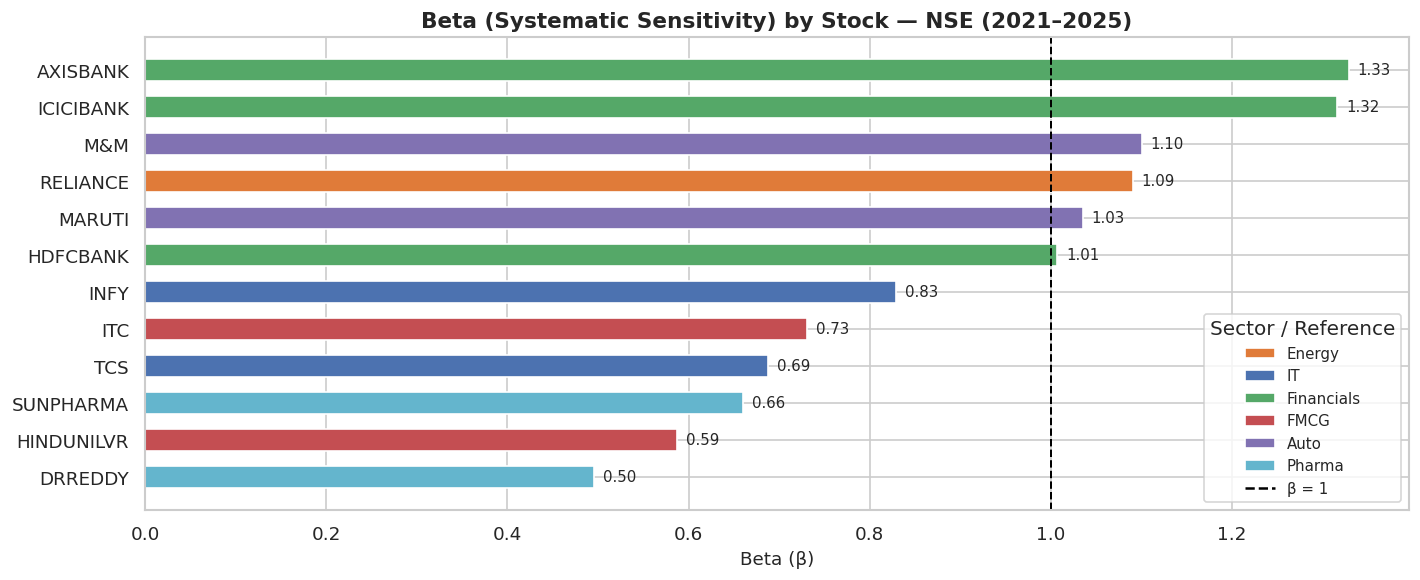

Saved: viz1_beta_by_stock.png


In [16]:
# ── VIZ 1: Beta by stock, coloured by sector ─────────────────────────────────
sector_palette = {
    'Energy'     : '#E07B39',
    'IT'         : '#4C72B0',
    'Financials' : '#55A868',
    'FMCG'       : '#C44E52',
    'Auto'       : '#8172B2',
    'Pharma'     : '#64B5CD',
}

plot_data = results.sort_values('Beta').reset_index()
colors    = plot_data['Sector'].map(sector_palette)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(plot_data['Company'], plot_data['Beta'],
               color=colors, edgecolor='white', height=0.6)

ax.axvline(1.0, color='black', linestyle='--', linewidth=1.2, label='β = 1 (market)')
ax.set_xlabel('Beta (β)', fontsize=11)
ax.set_title('Beta (Systematic Sensitivity) by Stock — NSE (2021–2025)', fontsize=13, fontweight='bold')

# Annotate bars
for bar, val in zip(bars, plot_data['Beta']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

# Legend for sectors
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, label=s) for s, c in sector_palette.items()]
ax.legend(handles=legend_handles, title='Sector', loc='lower right', fontsize=9)
ax.legend(handles=legend_handles + [plt.Line2D([0],[0], color='black',
          linestyle='--', label='β = 1')], title='Sector / Reference',
          loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('viz1_beta_by_stock.png', bbox_inches='tight')
plt.show()
print("Saved: viz1_beta_by_stock.png")

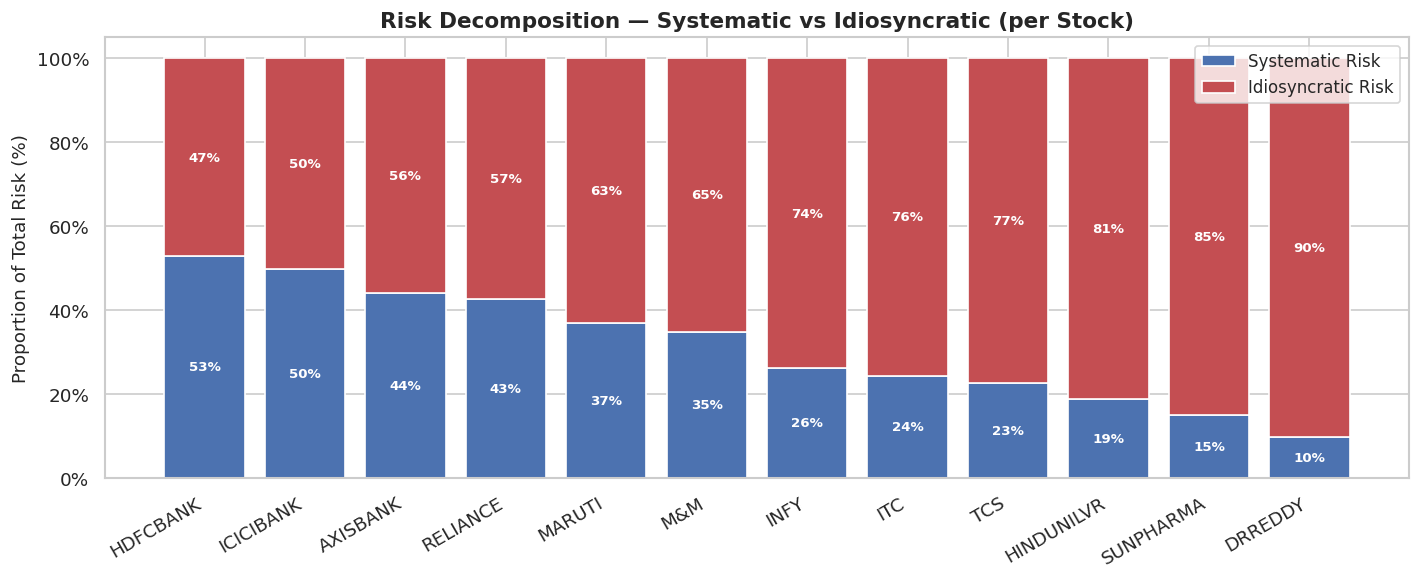

Saved: viz2_risk_decomposition.png


In [17]:
# ── VIZ 2: Stacked bar — Systematic vs Idiosyncratic risk % ─────────────────
plot2 = results.sort_values('Systematic_%', ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(plot2['Company'], plot2['Systematic_%'],
       label='Systematic Risk',    color='#4C72B0', edgecolor='white')
ax.bar(plot2['Company'], plot2['Idiosyncratic_%'],
       bottom=plot2['Systematic_%'],
       label='Idiosyncratic Risk', color='#C44E52', edgecolor='white')

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('Proportion of Total Risk (%)', fontsize=11)
ax.set_title('Risk Decomposition — Systematic vs Idiosyncratic (per Stock)', fontsize=13, fontweight='bold')
ax.set_xticklabels(plot2['Company'], rotation=30, ha='right')
ax.legend(fontsize=10)
ax.set_ylim(0, 105)

# Annotate systematic %
for i, row in plot2.iterrows():
    ax.text(i, row['Systematic_%']/2, f"{row['Systematic_%']:.0f}%",
            ha='center', va='center', color='white', fontsize=8, fontweight='bold')
    ax.text(i, row['Systematic_%'] + row['Idiosyncratic_%']/2,
            f"{row['Idiosyncratic_%']:.0f}%",
            ha='center', va='center', color='white', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('viz2_risk_decomposition.png', bbox_inches='tight')
plt.show()
print("Saved: viz2_risk_decomposition.png")